In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from DataManagement import DataViewer, DataHandler, ImprovedDataHandler
from ModelPipelines import *

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sksurv.linear_model import CoxnetSurvivalAnalysis

In [11]:
# Load data
df = pd.read_csv("./X_train/clinical_train.csv", index_col=0)
maf_df = pd.read_csv("./X_train/molecular_train.csv", index_col=0)
target_df = pd.read_csv("./target_train.csv", index_col=0)

init=ImprovedDataHandler(df,maf_df,target_df)
init._decode_chromosomes(maf_df)


,1,10,11,12,13,14,15,16,17,18,...,22,3,4,5,6,7,8,9,X,nb_mutations
ID,,,,,,,,,,,,,,,,,,,,,
P100000,0.000,0.0,0.083,0.000,0.0,0.0,0.000,0.0,0.000,0.0,...,0.000,0.4100,0.4300,0.795,0.0,0.0,0.0,0.000,0.0000,6
P100001,0.000,0.0,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.0,...,0.418,0.1010,0.0000,0.000,0.0,0.0,0.0,0.000,0.0000,2
P100002,0.000,0.0,0.000,0.000,0.0,0.0,0.000,0.0,0.597,0.0,...,0.000,0.1970,0.0000,0.000,0.0,0.0,0.0,0.000,0.0000,2
P100004,0.000,0.0,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.0,...,0.000,0.0000,0.0000,0.000,0.0,0.0,0.0,0.000,0.4691,1
P100006,0.000,0.0,0.000,0.286,0.0,0.0,0.000,0.0,0.372,0.0,...,0.068,0.0000,0.0555,0.000,0.0,0.0,0.0,0.065,0.0000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P132725,0.000,0.0,0.000,0.000,0.0,0.0,0.469,0.0,0.000,0.0,...,0.000,0.4970,0.0000,0.000,0.0,0.0,0.0,0.000,0.8060,5
P132726,0.000,0.0,0.269,0.000,0.0,0.0,0.000,0.0,0.000,0.0,...,0.000,0.0000,0.0000,0.000,0.0,0.0,0.0,0.000,0.0000,1
P132727,0.000,0.0,0.285,0.000,0.0,0.0,0.000,0.0,0.000,0.0,...,0.000,0.0000,0.0000,0.000,0.0,0.0,0.0,0.000,0.0000,2


In [16]:
# Load data
df = pd.read_csv("./X_train/clinical_train.csv", index_col=0)
maf_df = pd.read_csv("./X_train/molecular_train.csv", index_col=0)
target_df = pd.read_csv("./target_train.csv", index_col=0)

# Build and fit pipeline
data_handler = DefaultDataHandler(df, maf_df, target_df)
prepared_data = data_handler.prepare()

pipeline_builder = DefaultPipeline(prepared_data)
pipeline = pipeline_builder.build_pipeline()
pipeline
# # Fit the pipeline
# pipeline.fit(data_handler.df, data_handler.y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('drop_missing', ...), ('column_transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,threshold,0.2
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [21]:
from sksurv.util import Surv
X, y_df, float_cols, categorical_cols, binary_cols = prepared_data
y_surv = Surv.from_dataframe(
    event='OS_STATUS',   # 1 = event, 0 = censored
    time='OS_YEARS',
    data=y_df
)

pipeline.fit(X, y_surv)
transformed_data = pipeline[:-1].transform(X)

In [22]:
model = pipeline[-1]
model.fit(transformed_data, y_surv)

,n_estimators,100
,max_depth,None
,min_samples_split,6
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [23]:
from sksurv.metrics import concordance_index_censored

def cindex_scorer(self, estimator, X, y):
    pred = estimator.predict(X)
    event, time = y[y.dtype.names[0]], y[y.dtype.names[1]]
    return concordance_index_censored(event, time, pred)[0]

In [24]:
concordance_index_censored(y_surv['OS_STATUS'], y_surv['OS_YEARS'], model.predict(transformed_data))

(np.float64(0.8661168428019104),
 np.int64(2359585),
 np.int64(364741),
 np.int64(1),
 np.int64(1292))

In [26]:
# Clinical Data
df = pd.read_csv("./X_train/clinical_train.csv", index_col=0)
df_eval = pd.read_csv("./X_test/clinical_test.csv", index_col=0)

# Molecular Data
maf_df = pd.read_csv("./X_train/molecular_train.csv", index_col=0)
maf_eval = pd.read_csv("./X_test/molecular_test.csv", index_col=0)

target_df = pd.read_csv("./target_train.csv", index_col=0)

In [27]:
# columns to drop in molecular data
cols_to_drop = [
    "CHR", # the length of the chromosome is not relevant to the survival rate
    "START", # the position of the mutation is not relevant to the survival rate
    "END",
    "REF", # does not provide any information about the mutation
    "ALT", 
    "DEPTH" # it is a measure of the perf of measurement from the lab, not relevant
]

test = maf_df.drop(columns=cols_to_drop, axis=0)

In [28]:
mol_agg = maf_df.groupby("ID").agg(
    nb_mutations=("GENE", "count"),
    mean_vaf=("VAF", "mean"),
    max_vaf=("VAF", "max"),
)

final_df = df.join(mol_agg)

In [29]:
cyto = final_df['CYTOGENETICS'].str.lower()

cyto = cyto.str.replace(r'\[.*?\]', '', regex=True)  # enlève [20]
cyto = cyto.str.replace('onfish', '', regex=False)
cyto = cyto.str.strip()
cyto

ID
P132697                             46,xy,del(20)(q12)/46,xy
P132698                                                46,xx
P116889                          46,xy,t(3;3)(q25;q27)/46,xy
P132699                           46,xy,del(3)(q26q27)/46,xy
P132700                          46,xx,t(3;9)(p13;q22)/46,xx
                                 ...                        
P121828                                                46,xy
P121829    46,xy,del(13)(q12q14)/45,x,-y,del(13)(q12q14)/...
P121830              46,xy,del(20)(q11.2q13.1)/45,xy,idem,-7
P121853    46,xx,del(1)(p34)/45,xx,sl,-18/46,xx,sdl,+8/46,xx
P121834                                                46,xy
Name: CYTOGENETICS, Length: 3323, dtype: str

In [30]:
df['cyto_normal'] = cyto.str.fullmatch(r'46,(xx|xy)').astype(float)
df['cyto_complex'] = cyto.str.contains('complex', na=False).astype(int)
df['monosomy_7'] = cyto.str.contains(r'-7', na=False).astype(int)
df['trisomy_8'] = cyto.str.contains(r'\+8', na=False).astype(int)
df['del_5q'] = cyto.str.contains(r'del\(5', na=False).astype(int)
df['t_3_3'] = cyto.str.contains(r't\(3;3\)', na=False).astype(int)
df

,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,cyto_normal,cyto_complex,monosomy_7,trisomy_8,del_5q,t_3_3
ID,,,,,,,,,,,,,,
P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",0.0,0,0,0,0,0
P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",1.0,0,0,0,0,0
P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",0.0,0,0,0,0,1
P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",0.0,0,0,0,0,0
P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",0.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P121828,VU,1.0,3.70,2.53,0.53,8.9,499.0,"46,xy[20]",1.0,0,0,0,0,0
P121829,VU,0.0,4.20,2.40,0.22,10.6,49.0,"46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...",0.0,0,0,0,0,0
P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",0.0,0,1,0,0,0


In [31]:
df['n_abnormalities'] = cyto.str.count(r'del|add|dic|der|inv|t\(|\+|-')
df['cyto_abnormal'] = (~df['cyto_normal'].astype(bool)).astype(int)
df['cyto_mosaic'] = cyto.str.contains('/', na=False).astype(int)
df

,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,cyto_normal,cyto_complex,monosomy_7,trisomy_8,del_5q,t_3_3,n_abnormalities,cyto_abnormal,cyto_mosaic
ID,,,,,,,,,,,,,,,,,
P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",0.0,0,0,0,0,0,1.0,1,1
P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",1.0,0,0,0,0,0,0.0,0,0
P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",0.0,0,0,0,0,1,1.0,1,1
P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",0.0,0,0,0,0,0,1.0,1,1
P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",0.0,0,0,0,0,0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P121828,VU,1.0,3.70,2.53,0.53,8.9,499.0,"46,xy[20]",1.0,0,0,0,0,0,0.0,0,0
P121829,VU,0.0,4.20,2.40,0.22,10.6,49.0,"46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...",0.0,0,0,0,0,0,3.0,1,1
P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",0.0,0,1,0,0,0,2.0,1,1


In [32]:
df["CYTOGENETICS"]

ID
P132697                      46,xy,del(20)(q12)[2]/46,xy[18]
P132698                                                46,xx
P116889                   46,xy,t(3;3)(q25;q27)[8]/46,xy[12]
P132699                    46,xy,del(3)(q26q27)[15]/46,xy[5]
P132700                  46,xx,t(3;9)(p13;q22)[10]/46,xx[10]
                                 ...                        
P121828                                            46,xy[20]
P121829    46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...
P121830       46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]
P121853    46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...
P121834                                            46,xy[20]
Name: CYTOGENETICS, Length: 3323, dtype: str

In [33]:
dtm = DataViewer(final_df, target_df)

In [34]:
dtm.target_analysis()

,count,mean,std,min,25%,50%,75%,max
OS_YEARS,3173.0,2.480713,2.588259,0.0,0.652055,1.652055,3.572603,22.043836
OS_STATUS,3173.0,0.504255,0.500061,0.0,0.000000,1.000000,1.000000,1.000000


In [35]:
target_df.isna().sum()

OS_YEARS     150
OS_STATUS    150
dtype: int64

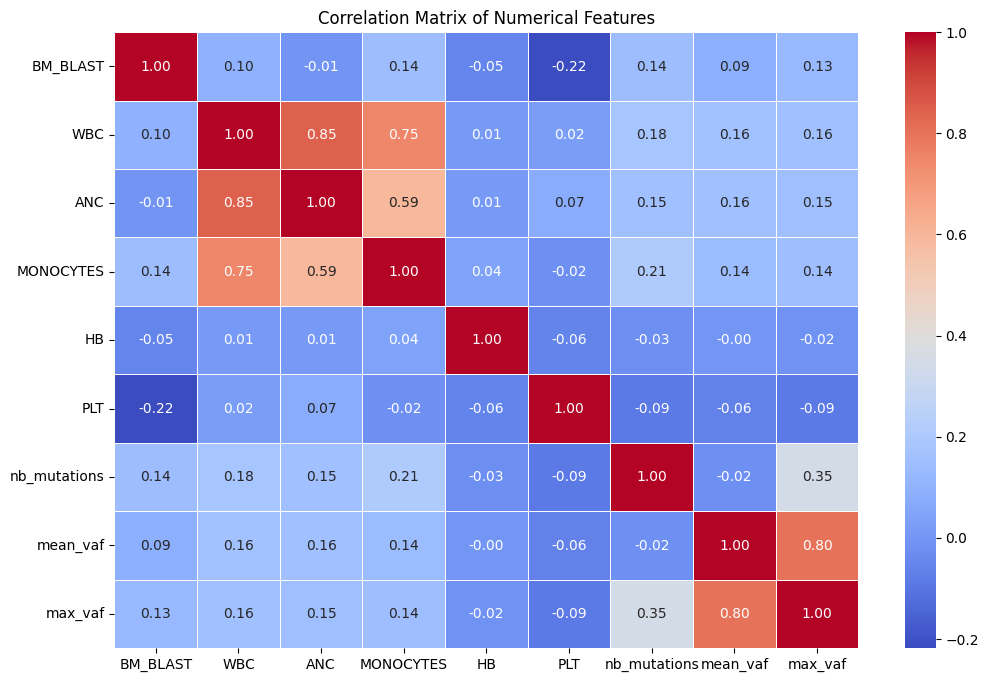

In [36]:
dtm.plot_correlation_matrix()

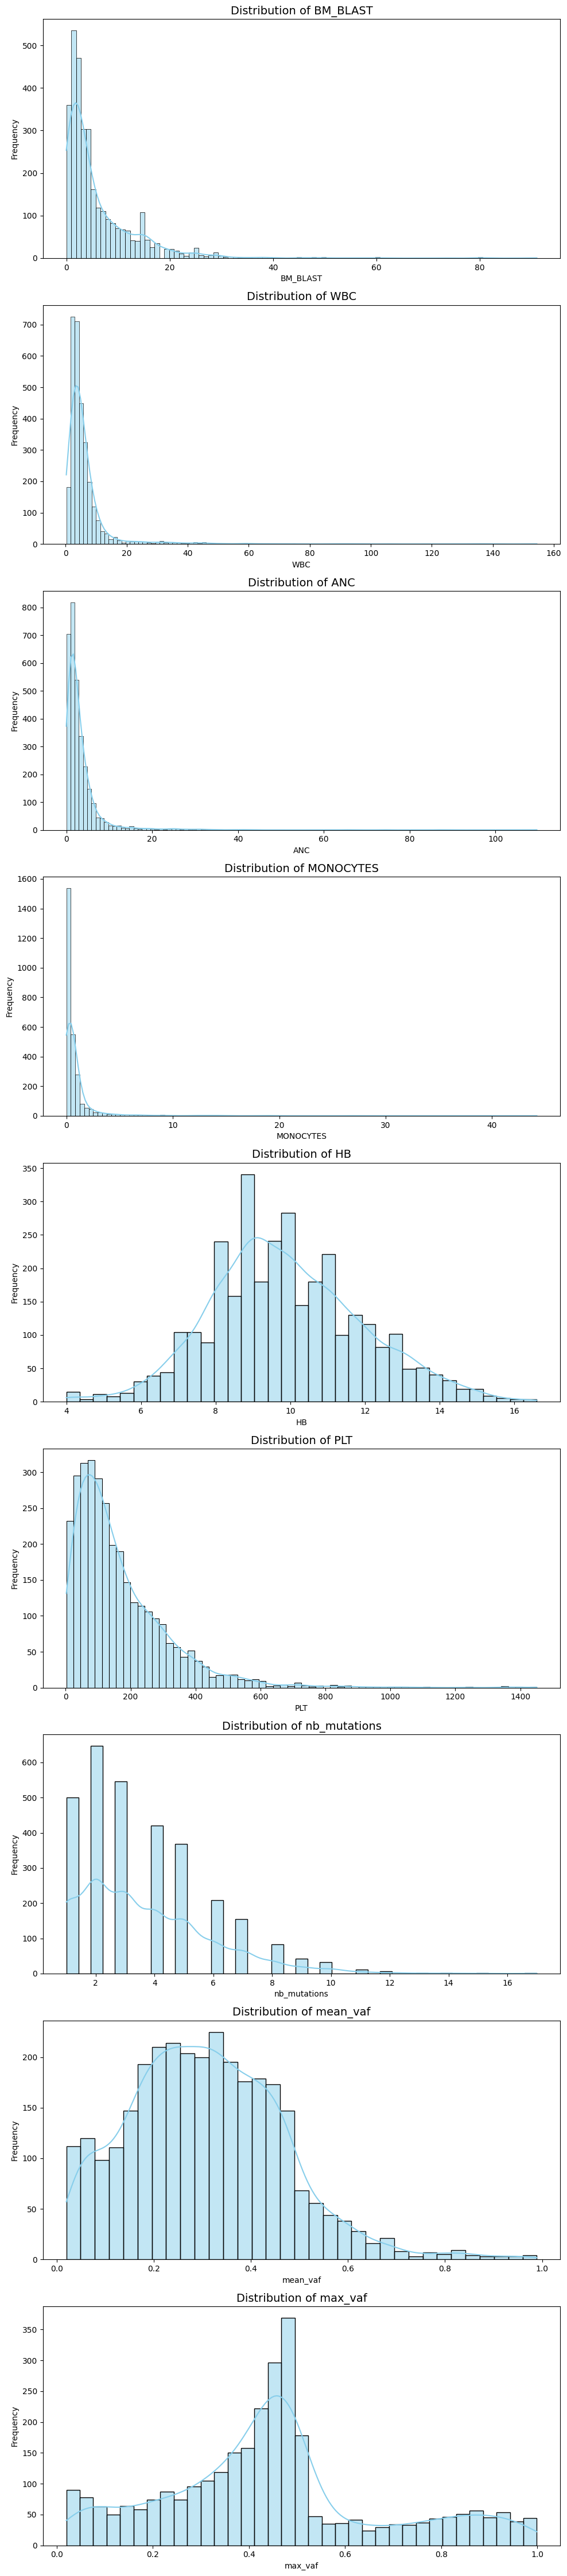

In [37]:
dtm.plot_float_distributions()

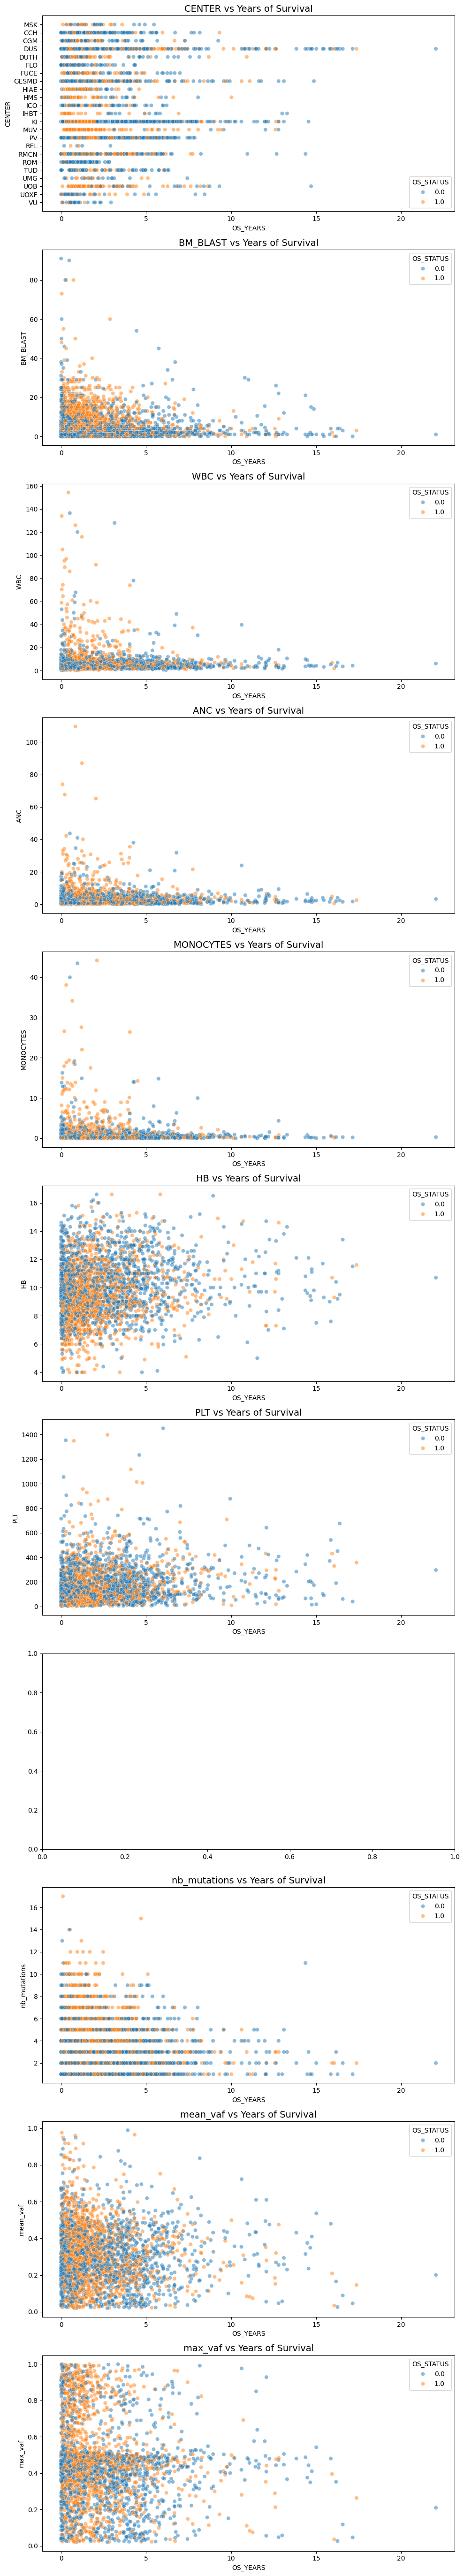

In [38]:
dtm.plot_distribution_by_target()

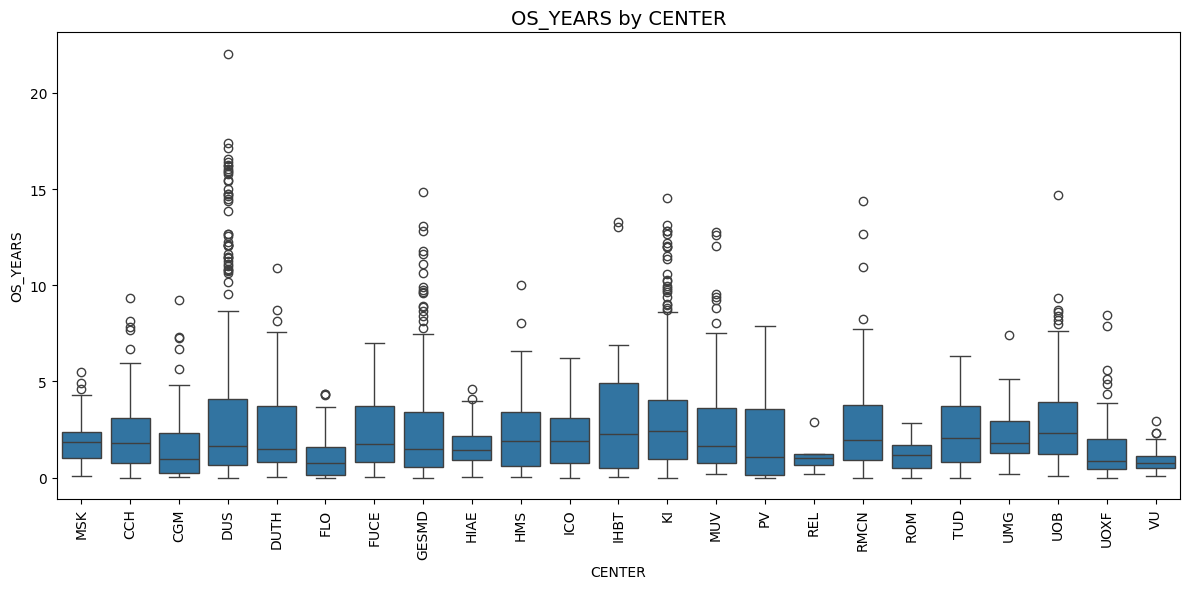

2026-03-02 18:55:15,860 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-02 18:55:15,867 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


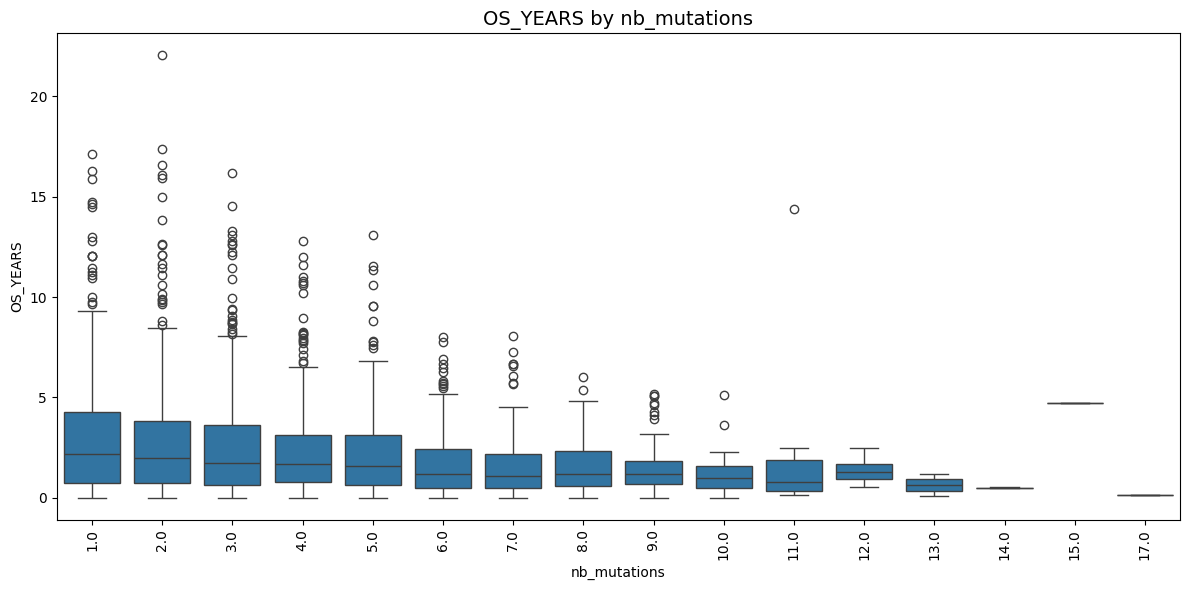

In [107]:
dtm.plot_categorical_boxplot(["CENTER", "nb_mutations"])

In [46]:
viewer = DataViewer(X, y_df)

display(viewer.stats_analysis().head(20))
display(viewer.target_analysis())

,dtype,count_nan,nan_percentage,distinct_values,count,mean,std,min,25%,50%,75%,max
CENTER,str,0,0.000000,23,3173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BM_BLAST,float64,79,2.489757,139,3094.0,6.071041,7.662941,0.0,1.0,3.0,8.0,91.0
WBC,float64,229,7.217145,690,2944.0,6.597417,10.405641,0.2,2.7,4.1,6.7,154.4
ANC,float64,141,4.443744,1019,3032.0,3.286438,5.308014,0.0,1.0,2.0,3.7,109.62
MONOCYTES,float64,544,17.144658,606,2629.0,0.971848,2.710523,0.0,0.149,0.37,0.792,44.2
HB,float64,75,2.363694,239,3098.0,9.861709,2.030977,4.0,8.5,9.7,11.1,16.6
PLT,float64,86,2.710369,581,3087.0,167.070758,150.234265,2.0,65.0,123.0,229.5,1451.0
cyto_normal,Int64,348,10.967539,2,2825.0,0.567788,0.495471,0.0,0.0,1.0,1.0,1.0
cyto_complex,Int64,348,10.967539,2,2825.0,0.004248,0.065048,0.0,0.0,0.0,0.0,1.0
monosomy_7,Int64,348,10.967539,2,2825.0,0.058761,0.235219,0.0,0.0,0.0,0.0,1.0


,count,mean,std,min,25%,50%,75%,max
OS_YEARS,3173.0,2.480713,2.588259,0.0,0.652055,1.652055,3.572603,22.043836
OS_STATUS,3173.0,0.504255,0.500061,0.0,0.000000,1.000000,1.000000,1.000000


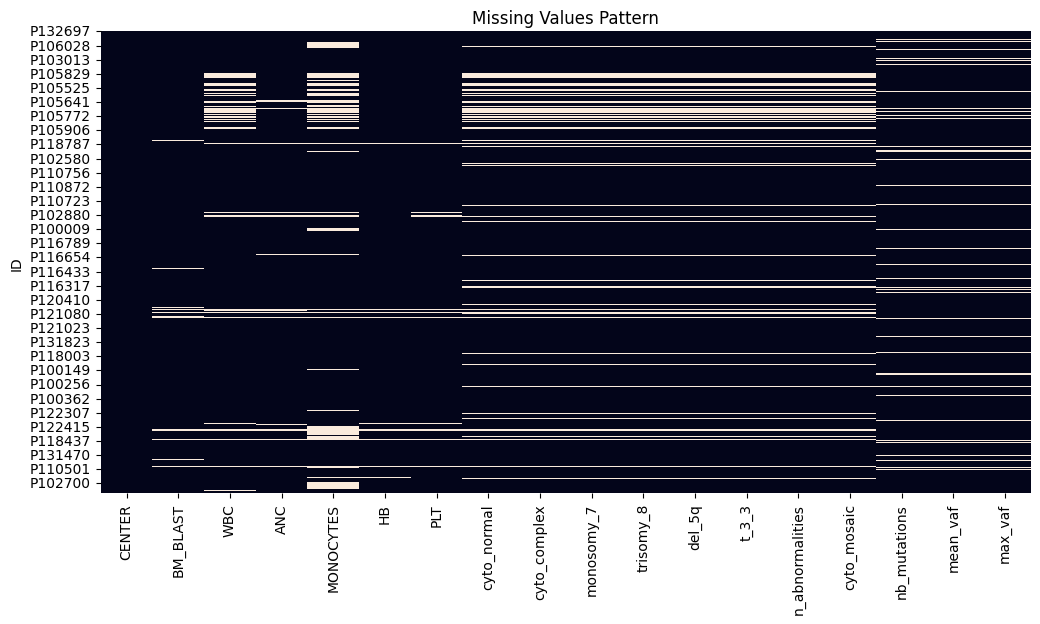

In [47]:
plt.figure(figsize=(12,6))
sns.heatmap(X.isna(), cbar=False)
plt.title("Missing Values Pattern")
plt.show()

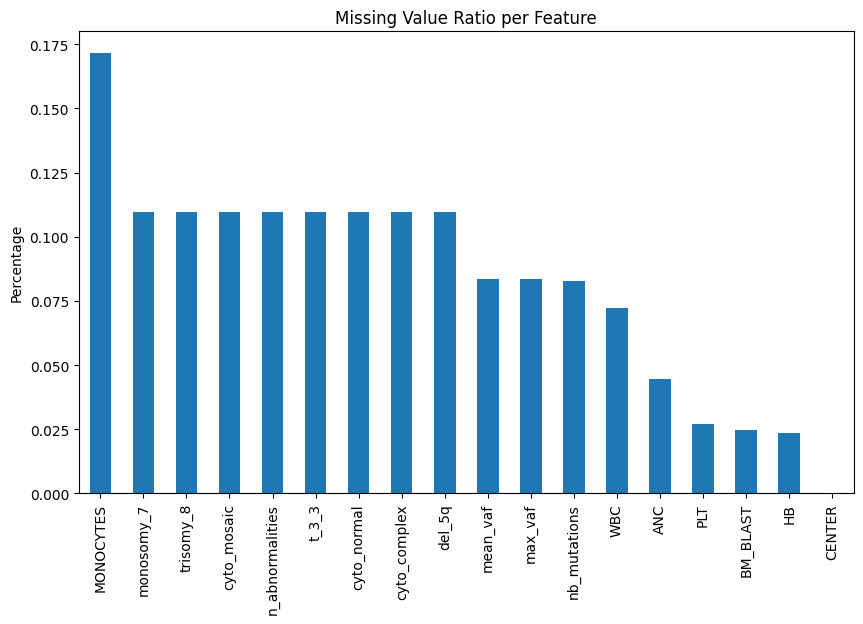

In [48]:
missing_ratio = X.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_ratio.plot(kind="bar")
plt.title("Missing Value Ratio per Feature")
plt.ylabel("Percentage")
plt.show()

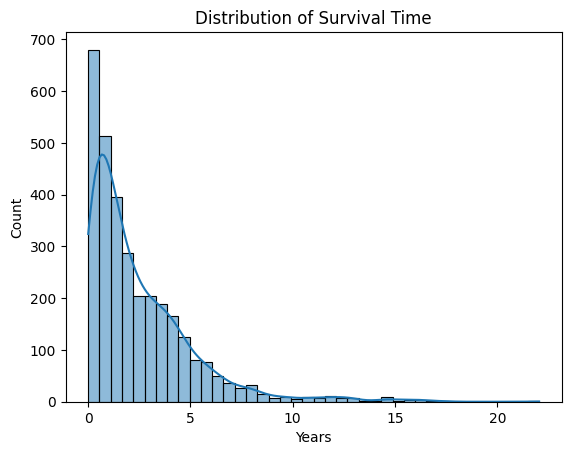

In [49]:
sns.histplot(y_df["OS_YEARS"], bins=40, kde=True)
plt.title("Distribution of Survival Time")
plt.xlabel("Years")
plt.show()

In [2]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
from DataManagement import DataHandler, DefaultDataHandler, ImprovedDataHandler
from ModelPipelines import DefaultPipeline
from sksurv.util import Surv
from config import PARAMS_RSF
from sksurv.metrics import concordance_index_ipcw,concordance_index_censored
import logging
import os
import numpy as np
from LearningCurve import learning_curve_analysis, RiskScorePlotter
from GridSearch import ModelSelection

In [3]:
# Load training data
df = pd.read_csv("./X_train/clinical_train.csv", index_col=0)
maf_df = pd.read_csv("./X_train/molecular_train.csv", index_col=0)
target_df = pd.read_csv("./target_train.csv", index_col=0)

# Build and fit pipeline
data_handler = ImprovedDataHandler(df, maf_df, target_df)
prepared_data = data_handler.prepare()
pipeline_builder = DefaultPipeline(prepared_data)
pipeline = pipeline_builder.build_pipeline()

# Save training columns to align test set
train_cols = prepared_data[0].columns.tolist()

# Prepare survival target
y_surv = Surv.from_dataframe(
    event='OS_STATUS',   # 1 = event, 0 = censored
    time='OS_YEARS',
    data=prepared_data[1]
)

# Grid search for best model
grid_search = ModelSelection(model=pipeline, param_grid=PARAMS_RSF, cv=5)
grid_search.fit(prepared_data[0], y_surv)
print("Best Parameters:", grid_search.best_params())
print("Best Score:", grid_search.best_score())

# --- Generate submission on test set (align columns with training) ---
clin_test = pd.read_csv("./X_test/clinical_test.csv", index_col=0)
try:
    maf_test = pd.read_csv("./X_test/molecular_test.csv", index_col=0)
except FileNotFoundError:
    maf_test = None

test_handler = DefaultDataHandler(clin_test, maf_test, None)
test_prepared = test_handler.prepare()
X_test_prepared = test_prepared[0]

# Align test columns to training columns (adds missing columns as NaN, drops extras)
X_test_aligned = X_test_prepared.reindex(columns=train_cols)


2026-03-04 22:00:43,597 - INFO - Initialized ModelSelection with model: Pipeline, cv: 5, n_jobs: -1
2026-03-04 22:00:43,597 - INFO - Starting Grid Search with 4 combinations


Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=20, model__n_estimators=200; total time=  22.9s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=20, model__n_estimators=200; total time=  23.1s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  23.5s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  23.9s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  24.7s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=20, model__n_estimators=200; total time=  24.6s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  2

/Users/a33619/Leukemia-Survival-Rate/.venv-2/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_features=sqrt, model__min_samples_leaf=20, model__min_samples_split=10, model__n_estimators=200; total time=  10.6s
[CV] END model__max_features=sqrt, model__min_samples_leaf=20, model__min_samples_split=10, model__n_estimators=200; total time=  10.7s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=200; total time=  13.3s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=200; total time=  14.0s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=200; total time=  13.7s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=200; total time=  13.8s
[CV] END model__max_features=sqrt, model__min_samples_leaf=20, model__min_samples_split=10, model__n_estimators=200; total time=   6.8s
[CV] END model__max_features=sqrt, model__min_sa

/Users/a33619/Leukemia-Survival-Rate/LearningCurve.py:97: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.lineplot(


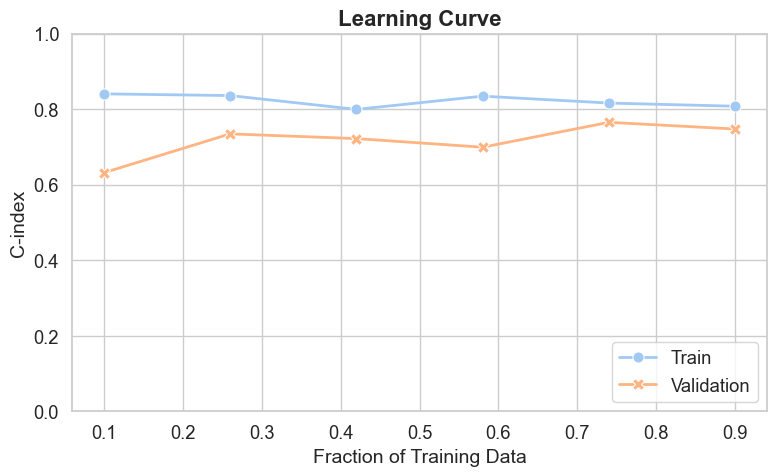

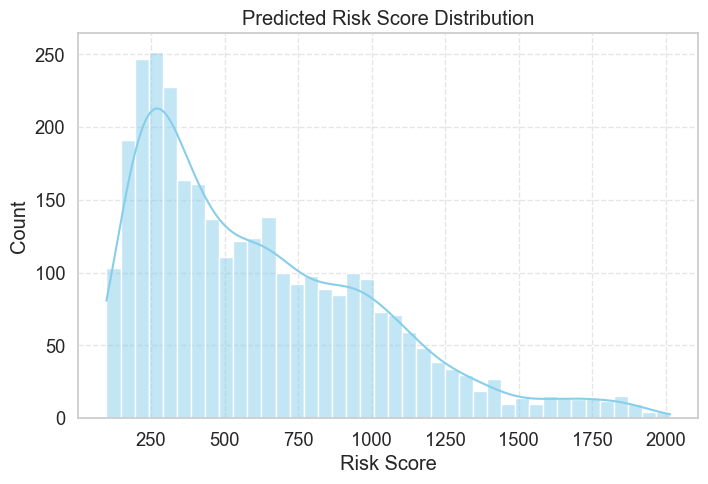

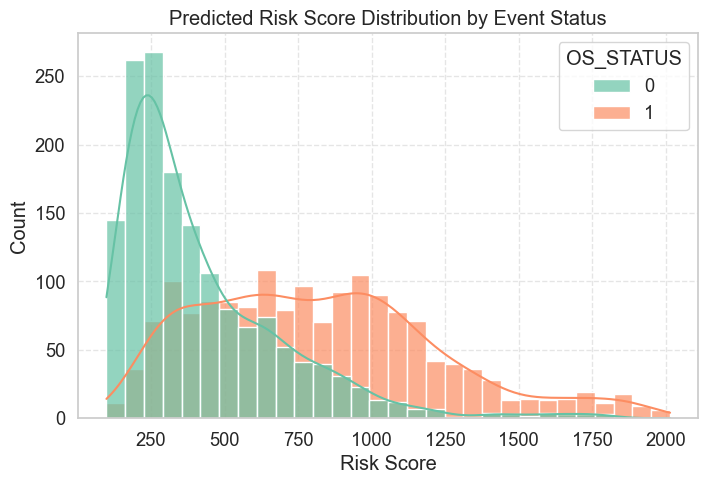

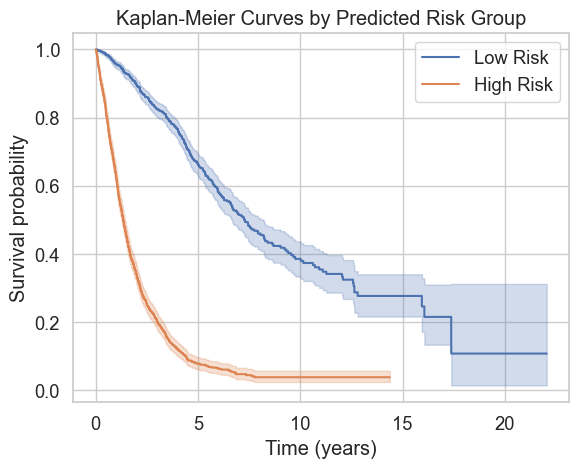

In [4]:
# --- Learning curve analysis ---
learning_curve_analysis(pipeline, prepared_data[0], y_surv)

# Use best model from grid search
best_model = grid_search.best_model

# Plot risk analysis
plotter = RiskScorePlotter(model=best_model, X=prepared_data[0], y=y_surv)
plotter.plot_overall_distribution()
plotter.plot_by_event_status()
plotter.plot_kaplan_meier()

In [5]:
# Choose 5 patients
sample_idx = X.index[:5]
X_sample = X.loc[sample_idx]

X_transformed = pipeline[:-1].transform(X_sample)  # all preprocessing

rsf_model = pipeline.named_steps["model"]
surv_funcs = rsf_model.predict_survival_function(X_transformed)

plt.figure(figsize=(10,6))
for i, fn in enumerate(surv_funcs):
    plt.step(fn.x, fn.y, where="post", label=f"Patient {i}")
plt.xlabel("Years")
plt.ylabel("Survival Probability")
plt.title("Predicted Survival Curves")
plt.legend()
plt.show()

NameError: name 'X' is not defined